# 🎮 Video Game Sales Analysis

### Python Data Analysis Project

**Dataset:** Video Game Sales Dataset  
**Source:** Kaggle

## 1. Project Definition

This project analyzes video game sales data to identify patterns in genres, platforms, publishers, regions, and sales trends.

## 2. Dataset Use Case

This dataset contains information about video games such as game name, platform, year, genre, publisher, regional sales, and global sales.

The dataset is used to analyze:
- Popular game genres
- Top-selling platforms and games
- Sales trends over the years
- Regional sales distribution
- Top publishers

## 3. Libraries and Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 4. Loading the Dataset

The dataset is loaded using Pandas for further analysis.

In [73]:
df = pd.read_csv("/vgsales.csv")

## 5. Data Exploration

The dataset is explored to understand its structure, size, columns, data types, and statistical information.

In [74]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [75]:
df.shape

(16598, 11)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [77]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 6. Data Cleaning

The dataset is checked for missing values, duplicate records, incorrect data types, and outliers.

### 6.1 Missing Values

Missing values are checked in each column.

In [78]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


### 6.2 Duplicate Records

Duplicate records are checked and removed if present.

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df = df.drop_duplicates()

### 6.3 Data Types

The data types of the columns are checked to ensure that the data is stored correctly.

In [81]:
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


### 6.4 Outlier Detection

Box plots are used to identify unusually high or low sales values.

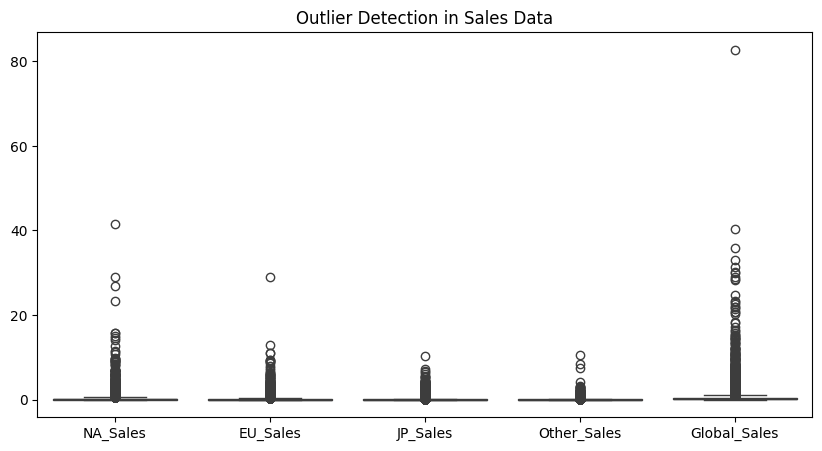

In [82]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']])
plt.title("Outlier Detection in Sales Data")
plt.show()

CLEAN THE DATA

Remove rows with missing Year/Publisher

In [83]:
df = df.dropna(subset=['Year', 'Publisher'])

Convert Year to integer

In [84]:
df['Year'] = df['Year'].astype(int)

Check cleaning

In [85]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

Duplicate rows: 0

Data types:
Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


# 7. Data Visualization

Different visualizations are used to analyze video game sales by genre, platform, year, region, games, and publishers.

### 7.1 Global Sales by Genre

This graph compares the total global sales of different video game genres.

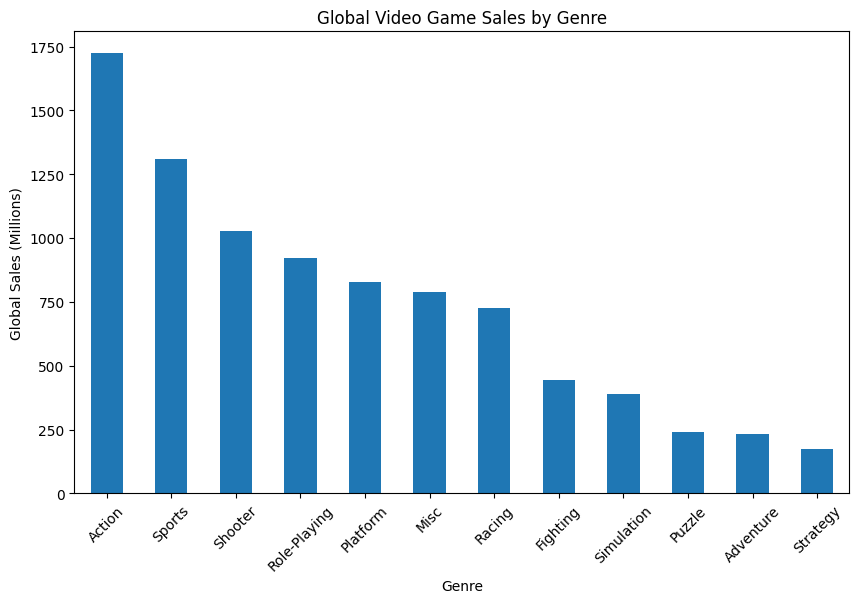

In [86]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
genre_sales.plot(kind='bar')
plt.title('Global Video Game Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

**Insight:** Action games have the highest total global sales, followed by Sports and Shooter games.

### 7.2 Top 10 Platforms by Global Sales

This graph shows the top 10 gaming platforms based on total global sales.

Which gaming platforms generated the highest global sales?

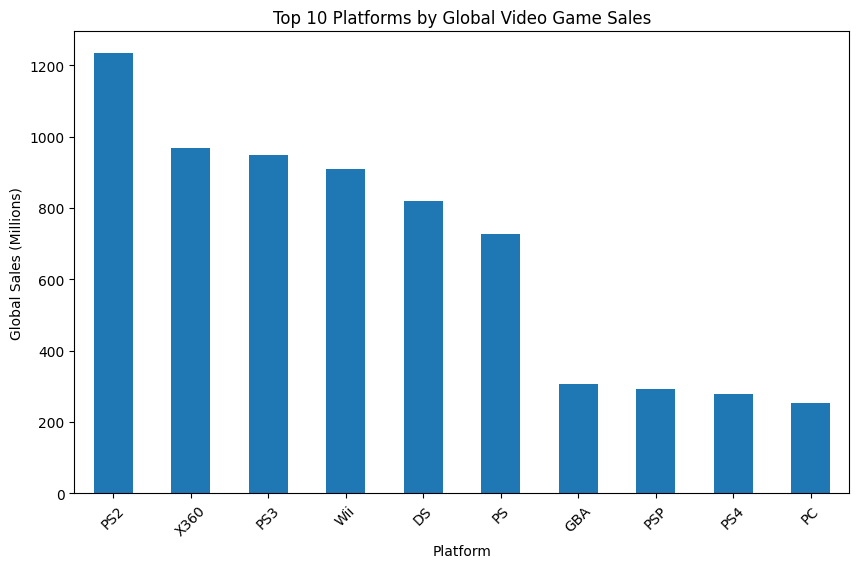

In [87]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
platform_sales.plot(kind='bar')
plt.title('Top 10 Platforms by Global Video Game Sales')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

**Insight:** PS2 has the highest global sales among the platforms shown, followed by X360 and PS3.

### 7.3 Global Video Game Sales by Year

This line graph shows the change in global video game sales over the years.

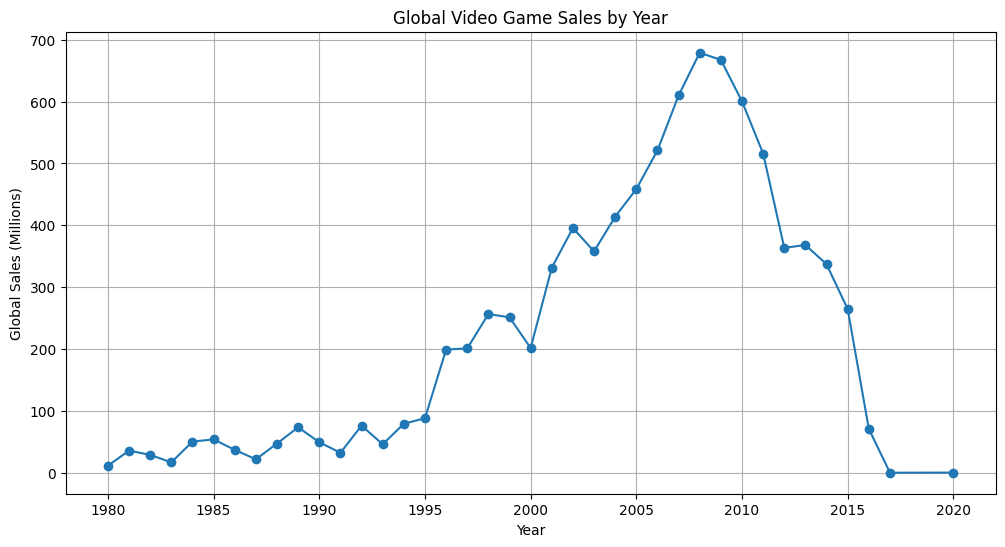

In [88]:
year_sales = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(year_sales.index, year_sales.values, marker='o')
plt.title('Global Video Game Sales by Year')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.grid(True)
plt.show()



**Insight:** Global video game sales reached their highest level around 2008–2009 and declined after 2010.

### 7.4 Regional Distribution of Video Game Sales

This pie chart shows the contribution of different regions to total video game sales.

Which region contributes the most to video game sales?


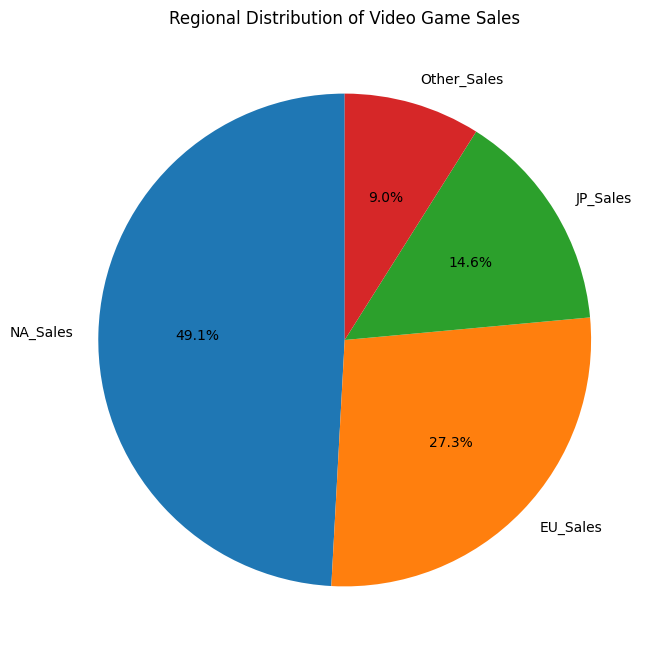

In [89]:
regional_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(8, 8))
plt.pie(regional_sales, labels=regional_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Regional Distribution of Video Game Sales')
plt.show()

**Insight:** North America contributes the largest share of sales at 49.1%, followed by Europe at 27.3%, Japan at 14.6%, and other regions at 9.0%.

### 7.5 Top 10 Best-Selling Video Games

This graph identifies the individual games with the highest global sales.

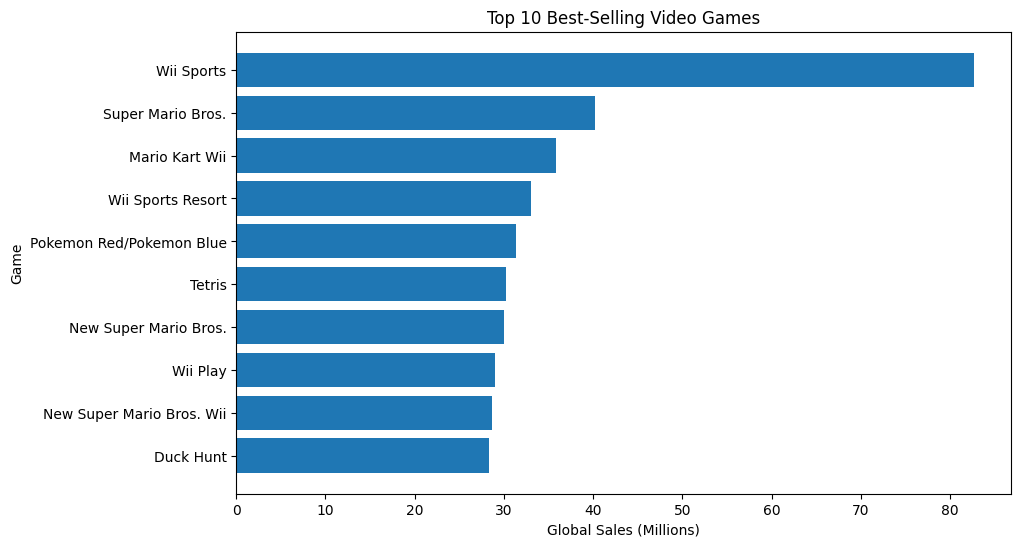

In [90]:
top_games = df.sort_values('Global_Sales', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_games['Name'], top_games['Global_Sales'])
plt.title('Top 10 Best-Selling Video Games')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Game')
plt.gca().invert_yaxis()
plt.show()

**Insight:** Wii Sports is the best-selling game in the dataset with approximately 82.74 million global sales.

### 7.6 Top 10 Publishers by Global Sales

This graph compares the global sales of the top 10 publishers.

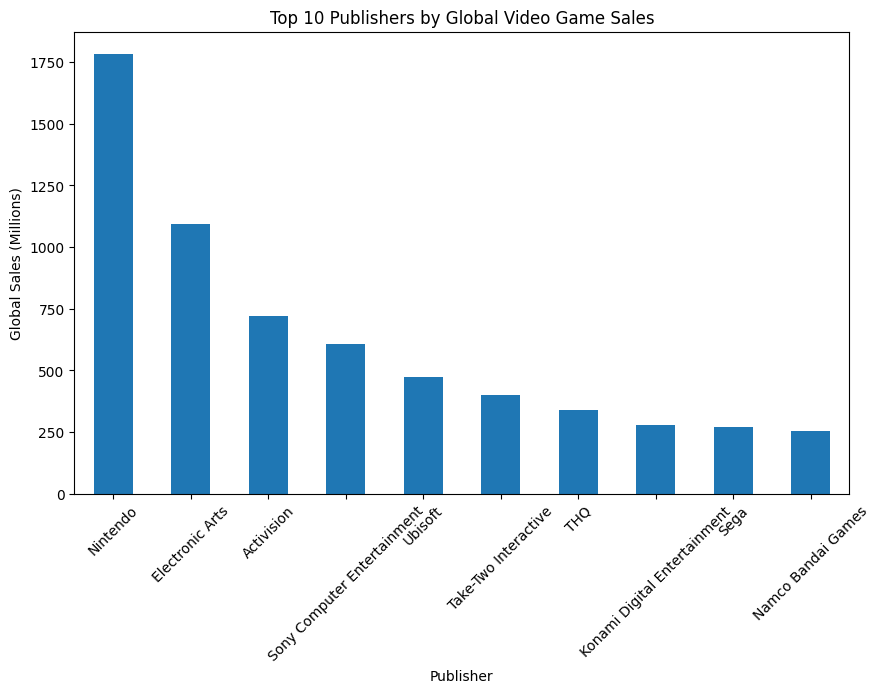

In [91]:
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
publisher_sales.plot(kind='bar')
plt.title('Top 10 Publishers by Global Video Game Sales')
plt.xlabel('Publisher')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

**Insight:** Major publishers account for a significant share of total global video game sales.

### 7.7 Genre-wise Regional Sales

This graph compares the sales of different game genres across different regions.

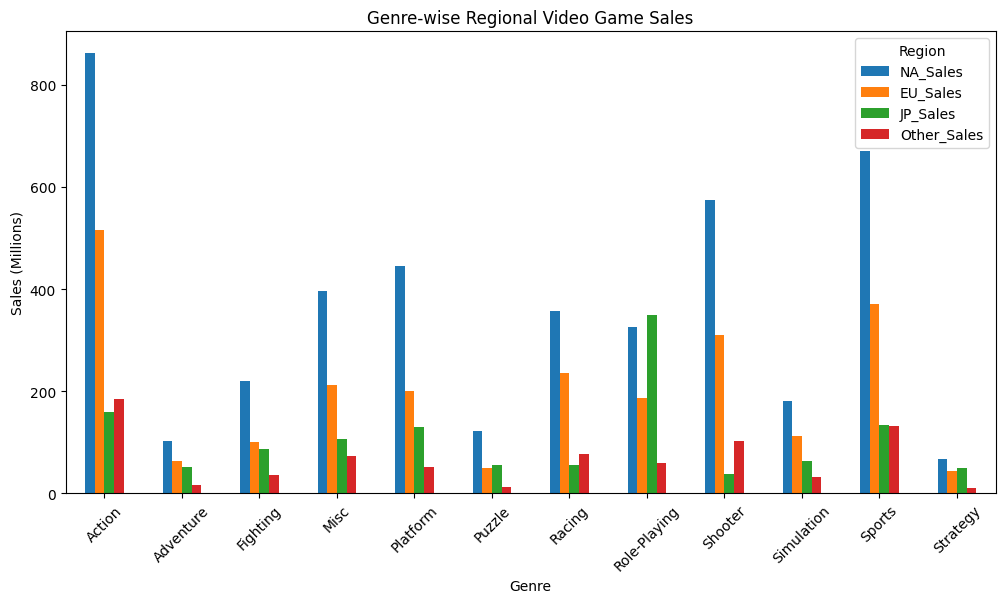

In [92]:
genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

genre_region.plot(kind='bar', figsize=(12, 6))

plt.title('Genre-wise Regional Video Game Sales')
plt.xlabel('Genre')
plt.ylabel('Sales (Millions)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.show()

**Insight:** Regional sales vary across genres, with North America generally contributing the largest sales across many genres.

# 8. Key Findings

- Action is the highest-selling video game genre.
- PS2 has the highest global sales among the platforms analyzed.
- Global sales reached their highest level around 2008–2009.
- North America contributes the largest share of regional sales.
- Wii Sports is the best-selling individual game in the dataset.
- Major publishers account for a significant portion of global sales.
- Different genres show different sales patterns across regions.

# 9. Conclusion

The analysis of the Video Game Sales dataset helped identify important patterns in video game sales.

The results provide insights into popular genres, platforms, games, publishers, regions, and yearly sales trends.

Data cleaning and visualization helped convert the raw dataset into meaningful information about the video game industry.